In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import shap
from sklearn.preprocessing import LabelEncoder
import pingouin as pg



### Loading in the full (2268) uncorrected radiomic csv

In [3]:
df_combined_uncorr = pd.read_csv('../data/All_features_uncorrected_all_tumours_with_metadata.csv')
df_combined_uncorr["Model"] = df_combined_uncorr["Model"].str.lower()
df_combined_uncorr


,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,PatientName,Model,GLbins,Wavelength,Reconstruction
0,69.142880,290.878683,4.448008e+09,4.636961,99.644165,23.988499,1506.465942,80.712806,167.184233,136.090408,...,0.649439,0.000213,9857.477189,0.011104,5.653971,10,basal,128,700,BP
1,68.959734,246.576346,3.275936e+09,4.593670,80.613131,24.513340,1244.968140,64.953736,148.365253,123.751446,...,0.613472,0.000216,9090.936807,0.010184,5.597988,10,basal,128,730,BP
2,70.308770,265.578290,3.766853e+09,4.614533,87.411236,24.715534,1360.987915,71.373395,156.751060,129.119141,...,0.680027,0.000209,9797.183512,0.011258,5.547308,10,basal,128,750,BP
3,69.735306,273.831262,4.000455e+09,4.573273,91.426805,24.677900,1426.273926,74.664145,160.247312,131.045944,...,0.648330,0.000207,9433.435006,0.010615,5.514328,10,basal,128,760,BP
4,68.767374,252.913724,3.433929e+09,4.613481,83.389416,24.597626,1282.152344,67.249362,150.974229,125.121998,...,0.631979,0.000218,9379.392808,0.010543,5.812234,10,basal,128,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,992.082990,4457.898047,1.070236e+12,1.369536,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,2080.059937,...,286.869851,0.000104,6.681988,0.002877,0.005507,98,basal,8,770,MB
2264,851.154541,4067.293140,8.697697e+11,1.501392,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,1894.330383,...,310.723250,0.000111,6.738676,0.003780,0.005968,98,basal,8,800,MB
2265,838.989789,4029.269922,8.527069e+11,1.469264,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,1876.432617,...,308.923560,0.000117,6.501626,0.003656,0.006386,98,basal,8,820,MB
2266,878.749854,4083.819263,8.834429e+11,1.551741,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,1926.486694,...,306.856707,0.000115,6.690178,0.004198,0.005954,98,basal,8,840,MB


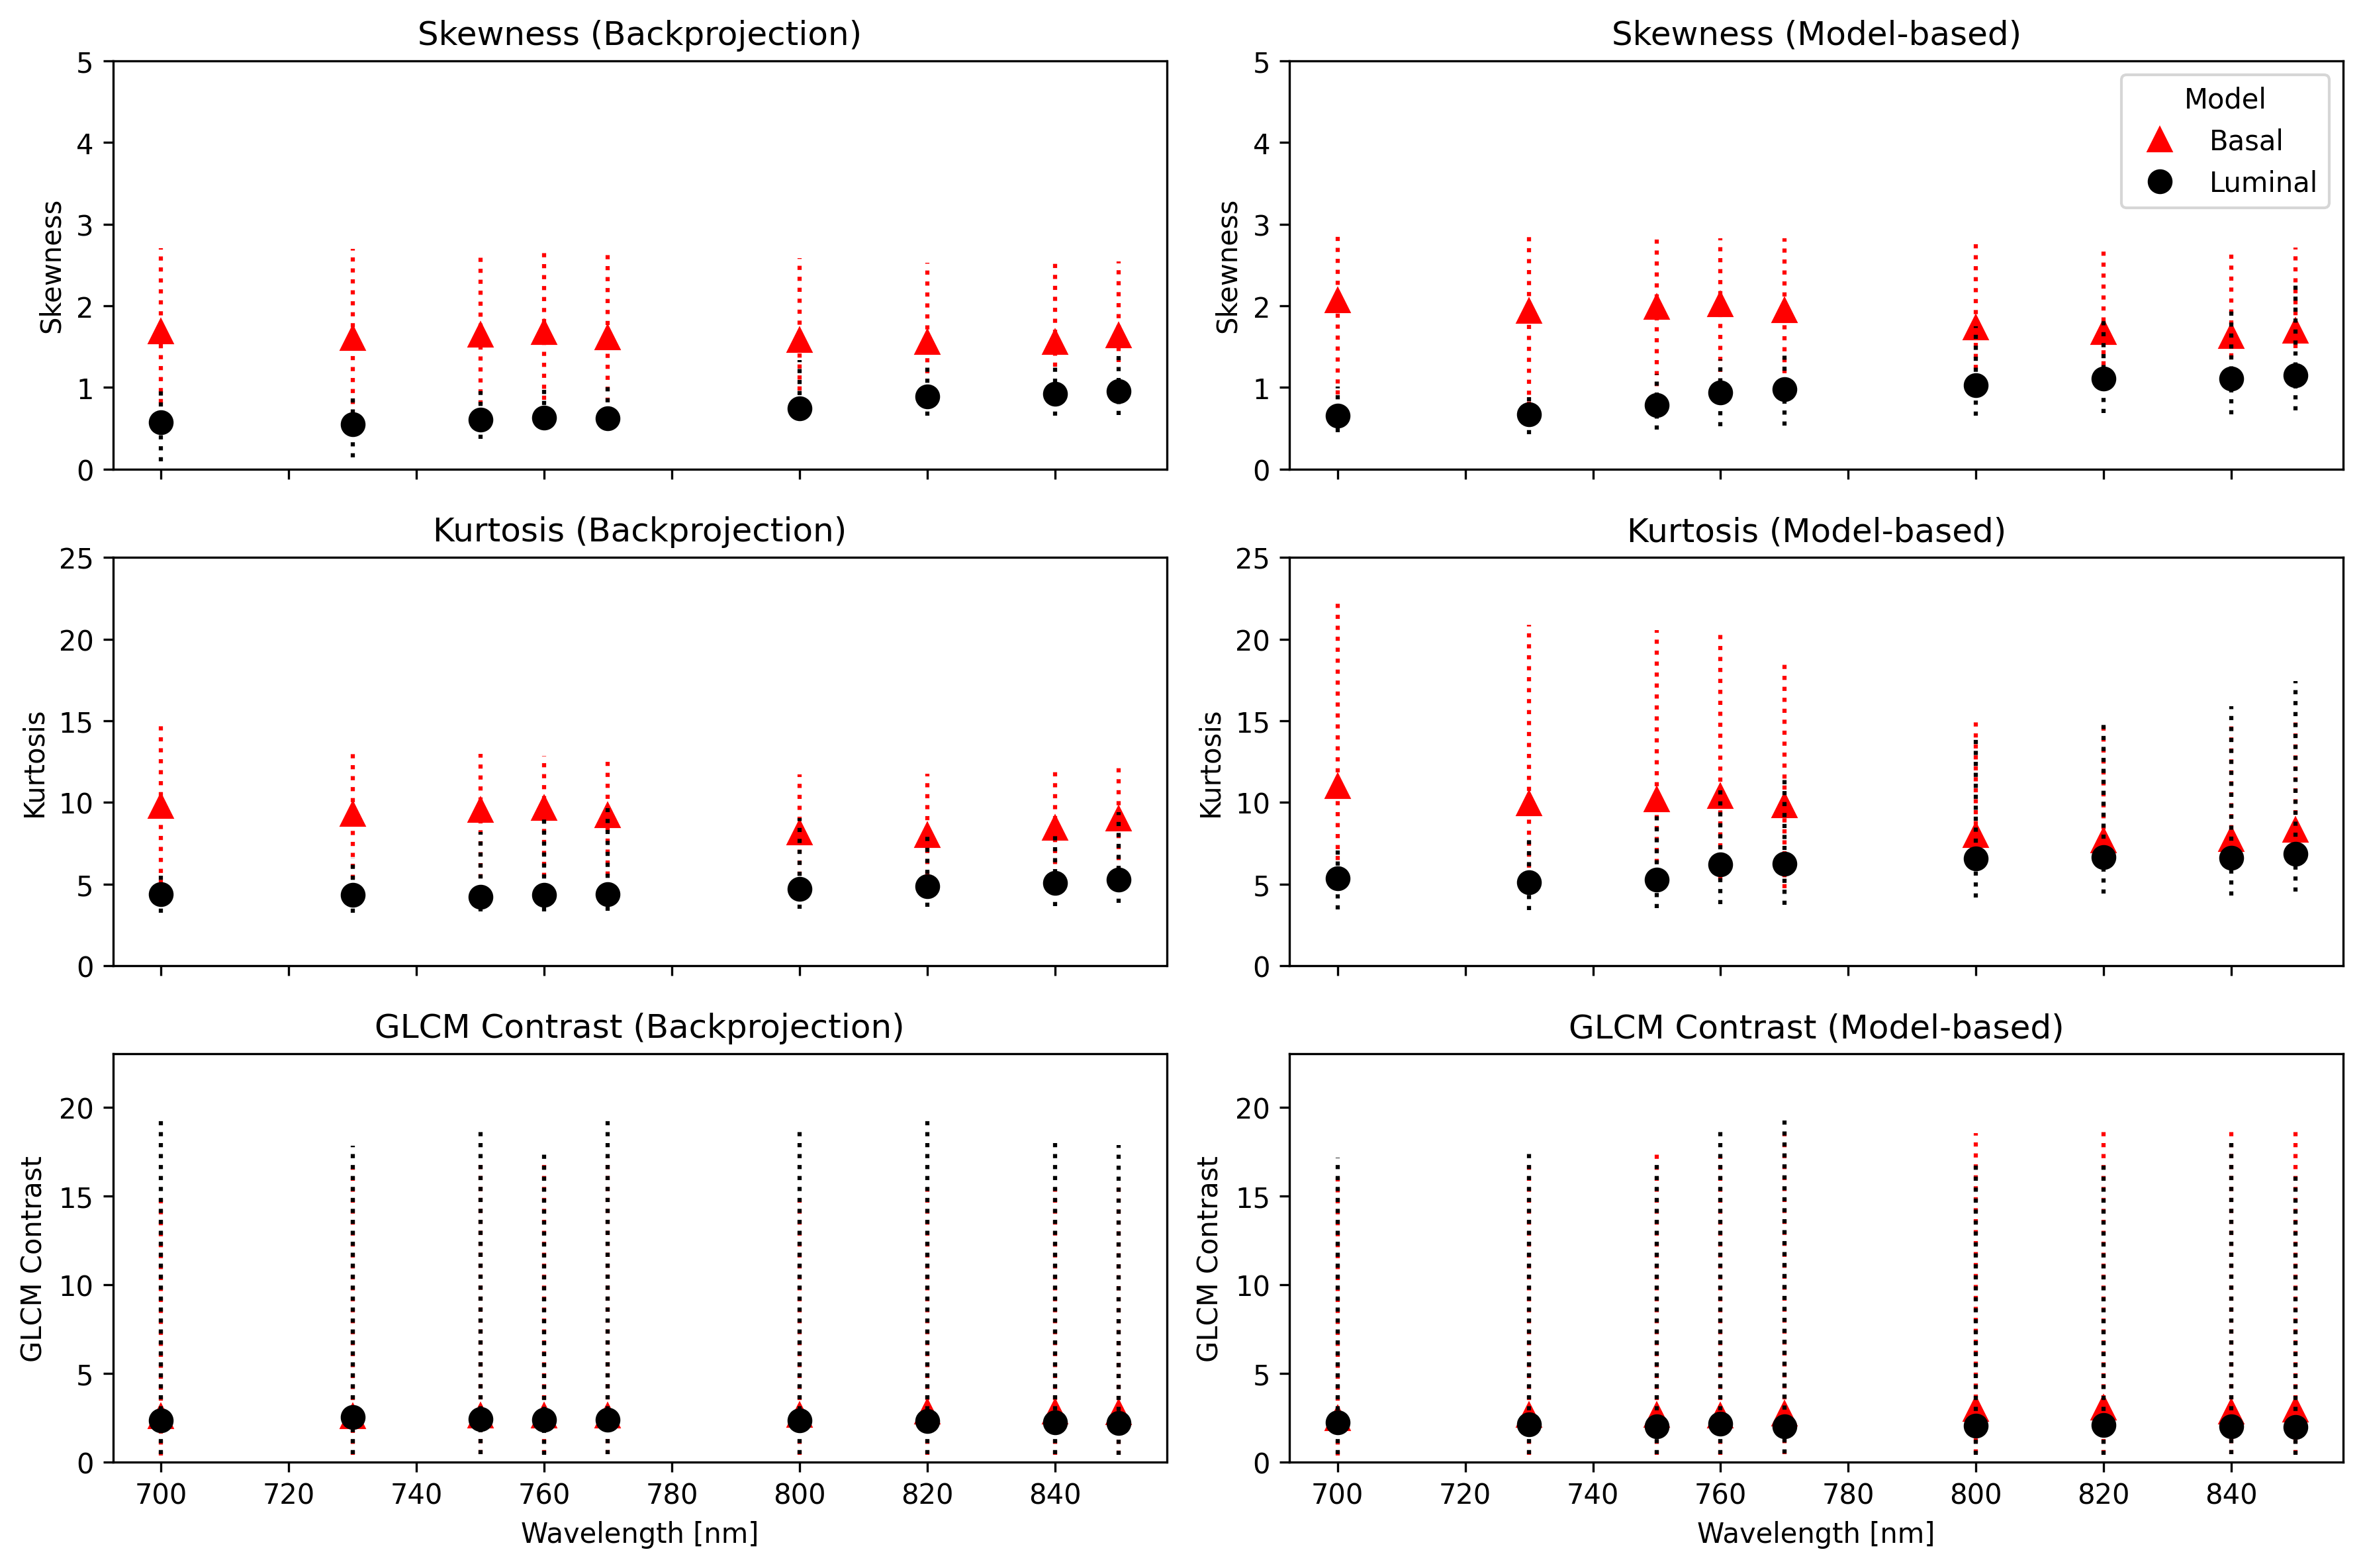

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define parameters
features = ["original_firstorder_Skewness", "original_firstorder_Kurtosis", "original_glcm_Contrast"]
titles = ["Skewness", "Kurtosis", "GLCM Contrast"]
y_lims = [(0, 5), (0, 25), (0, 23)]
recons = ["BP", "MB"]
colors = {"basal": "red", "luminal": "black"}
markers = {"basal": "^", "luminal": "o"}

# Create 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True, dpi=300)

for col, recon in enumerate(recons):
    for row, feature in enumerate(features):
        ax = axs[row, col]
        df_sub = df_combined_uncorr[df_combined_uncorr["Reconstruction"] == recon]

        for model in ["basal", "luminal"]:
            df_model = df_sub[df_sub["Model"] == model]
            grouped = df_model.groupby("Wavelength")[feature]
            med = grouped.median()
            iqr_min = grouped.quantile(0.25)
            iqr_max = grouped.quantile(0.75)
            # print(med)

            wl = med.index.values
            ax.plot(wl, med.values, markers[model], color=colors[model],
                    label=model.capitalize() if row == 0 else "", markersize=8)
            ax.vlines(wl, iqr_min.values, iqr_max.values,
                      color=colors[model], linestyle='dotted')

        ax.set_title(f"{titles[row]} ({'Backprojection' if recon == 'BP' else 'Model-based'})")
        ax.set_ylim(y_lims[row])
        if row == 2:
            ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel(titles[row])

        if row == 0 and col == 1:
            ax.legend(title="Model", loc="upper right")

plt.tight_layout()
# Save the figure
plt.savefig("../plots/IQR_plots_uncorrected.png", dpi=300, bbox_inches='tight')
plt.show()


### Feature Selection (Uses Corrected Data)

In [5]:
df_combined = pd.read_csv('../data/All_features_all_tumours_with_metadata.csv')
df_combined

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,Model,GLbins,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,basal,8,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,basal,8,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,basal,8,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,basal,8,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,basal,8,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,basal,256,770,MB
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,basal,256,800,MB
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,basal,256,820,MB
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,basal,256,840,MB


### KW Test

In [6]:
# Define numeric features
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns
target_col = "Model"

pvals = []
for col in feature_cols:
    groups = [group[col].values for _, group in df_combined.groupby(target_col)]
    _, p = kruskal(*groups)
    pvals.append(p)

# BH correction
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.25, method='fdr_bh')

# Assemble results
kw_df = pd.DataFrame({
    "Feature": feature_cols,
    "p_value": pvals,
    "p_adj": pvals_corrected,
    "Keep": reject
}).set_index("Feature")

selected_features_kw = kw_df[kw_df["Keep"]].index.tolist()
print(f"✅ {len(selected_features_kw)} features selected after BH correction (FDR < 0.25)")

✅ 69 features selected after BH correction (FDR < 0.25)


### Correlation Filtering

In [7]:
df_selected = df_combined[["PatientName", "Model"] + selected_features_kw].copy()
scores = {f: 1 - kw_df.loc[f, "p_adj"] for f in selected_features_kw}

selected_features = set(selected_features_kw)
dropped_features = set()

for i, key1 in enumerate(selected_features_kw):
    for key2 in selected_features_kw[i + 1:]:
        if key1 in dropped_features or key2 in dropped_features:
            continue

        try:
            result = pg.rm_corr(data=df_selected, x=key1, y=key2, subject="PatientName")
            r = result["r"].values[0]

            if r > 0.9:
                score1 = scores.get(key1, 0)
                score2 = scores.get(key2, 0)

                if score2 > score1:
                    dropped_features.add(key1)
                elif score1 > score2:
                    dropped_features.add(key2)
                else:
                    # Tie: drop second one arbitrarily
                    dropped_features.add(key2)

        except Exception as e:
            print(f"⚠️ Failed correlation between {key1} and {key2}: {e}")

# Final selection
final_features = list(selected_features - dropped_features)
print(f"✅ {len(final_features)} features selected after rm_corr filtering")

# Optional: keep only final features in dataframe
df_final = df_combined[["PatientName", "Model"] + final_features]

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-pac

✅ 34 features selected after rm_corr filtering


In [8]:
final_features

['NGTDM Busyness',
 'GLRLM GrayLevelNonUniformity',
 'GLSZM LowGrayLevelZoneEmphasis',
 'GLCM MCC',
 'GLRLM GrayLevelVariance',
 'GLCM Idmn',
 'GLRLM RunEntropy',
 'FO Minimum',
 'GLRLM LongRunLowGrayLevelEmphasis',
 'GLCM Imc1',
 'GLSZM SmallAreaEmphasis',
 'FO Skewness',
 'GLCM Imc2',
 'GLRLM GrayLevelNonUniformityNormalized',
 'NGTDM Strength',
 'FO Kurtosis',
 'GLRLM RunLengthNonUniformity',
 'FO 10Percentile',
 'GLDM SmallDependenceLowGrayLevelEmphasis',
 'GLRLM LongRunHighGrayLevelEmphasis',
 'FO 90Percentile',
 'GLCM ClusterProminence',
 'FO Variance',
 'GLCM Idn',
 'GLDM DependenceNonUniformityNormalized',
 'GLSZM ZoneVariance',
 'GLDM GrayLevelVariance',
 'GLCM Contrast',
 'GLSZM GrayLevelNonUniformity',
 'GLSZM GrayLevelNonUniformityNormalized',
 'GLCM ClusterShade',
 'NGTDM Coarseness',
 'GLCM MaximumProbability',
 'GLCM ClusterTendency']

### Classification

In [14]:
# Inputs
X = df_combined[final_features]
y = df_combined["Model"]

# Use stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Classifier setup
models = {
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=1.0
    ),
    "SVM (RBF kernel)": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1.0,
            gamma=0.05,
            tol=1e-3,
            probability=True,
            random_state=42
        )
    )
}

# Run CV
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"✅ {name}: {scores.mean():.3f} ± {scores.std():.3f}")


✅ Random Forest: 0.954 ± 0.015
✅ Gradient Boosting: 1.000 ± 0.000
✅ SVM (RBF kernel): 0.987 ± 0.006


### SHAP (All folds)

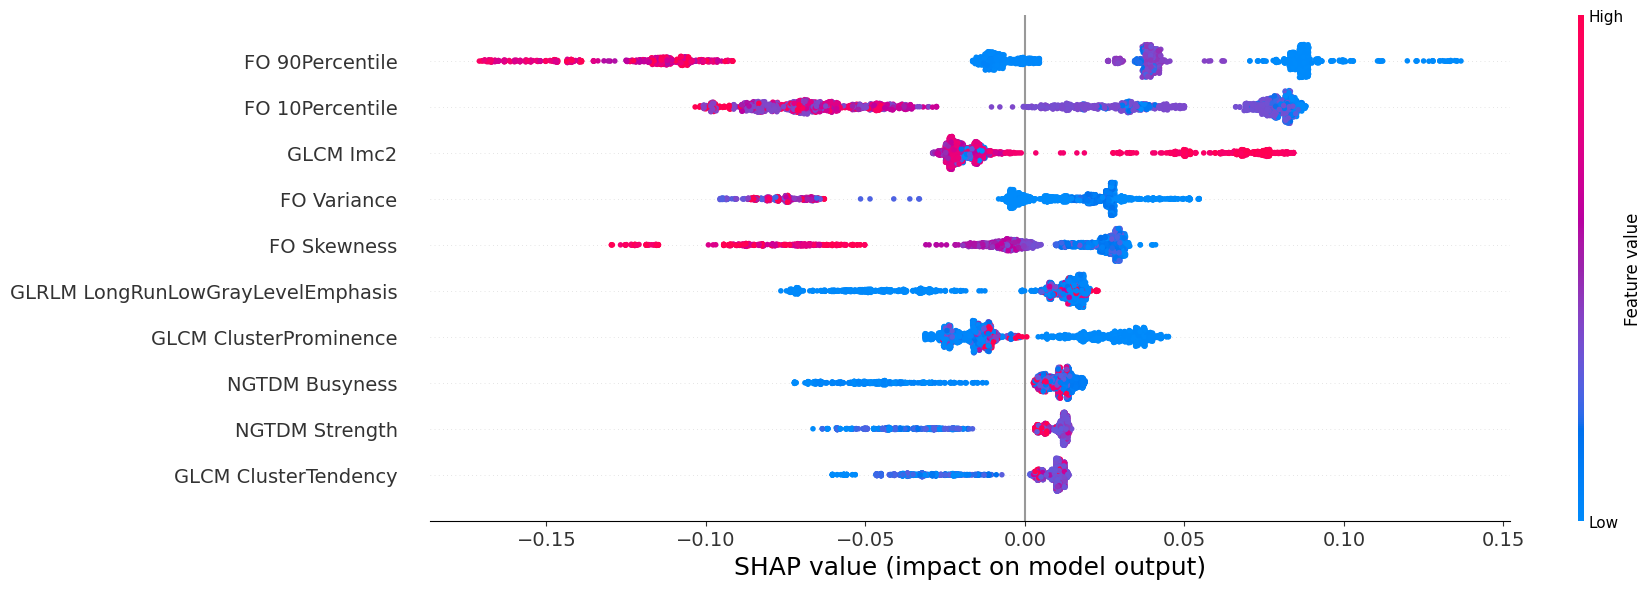

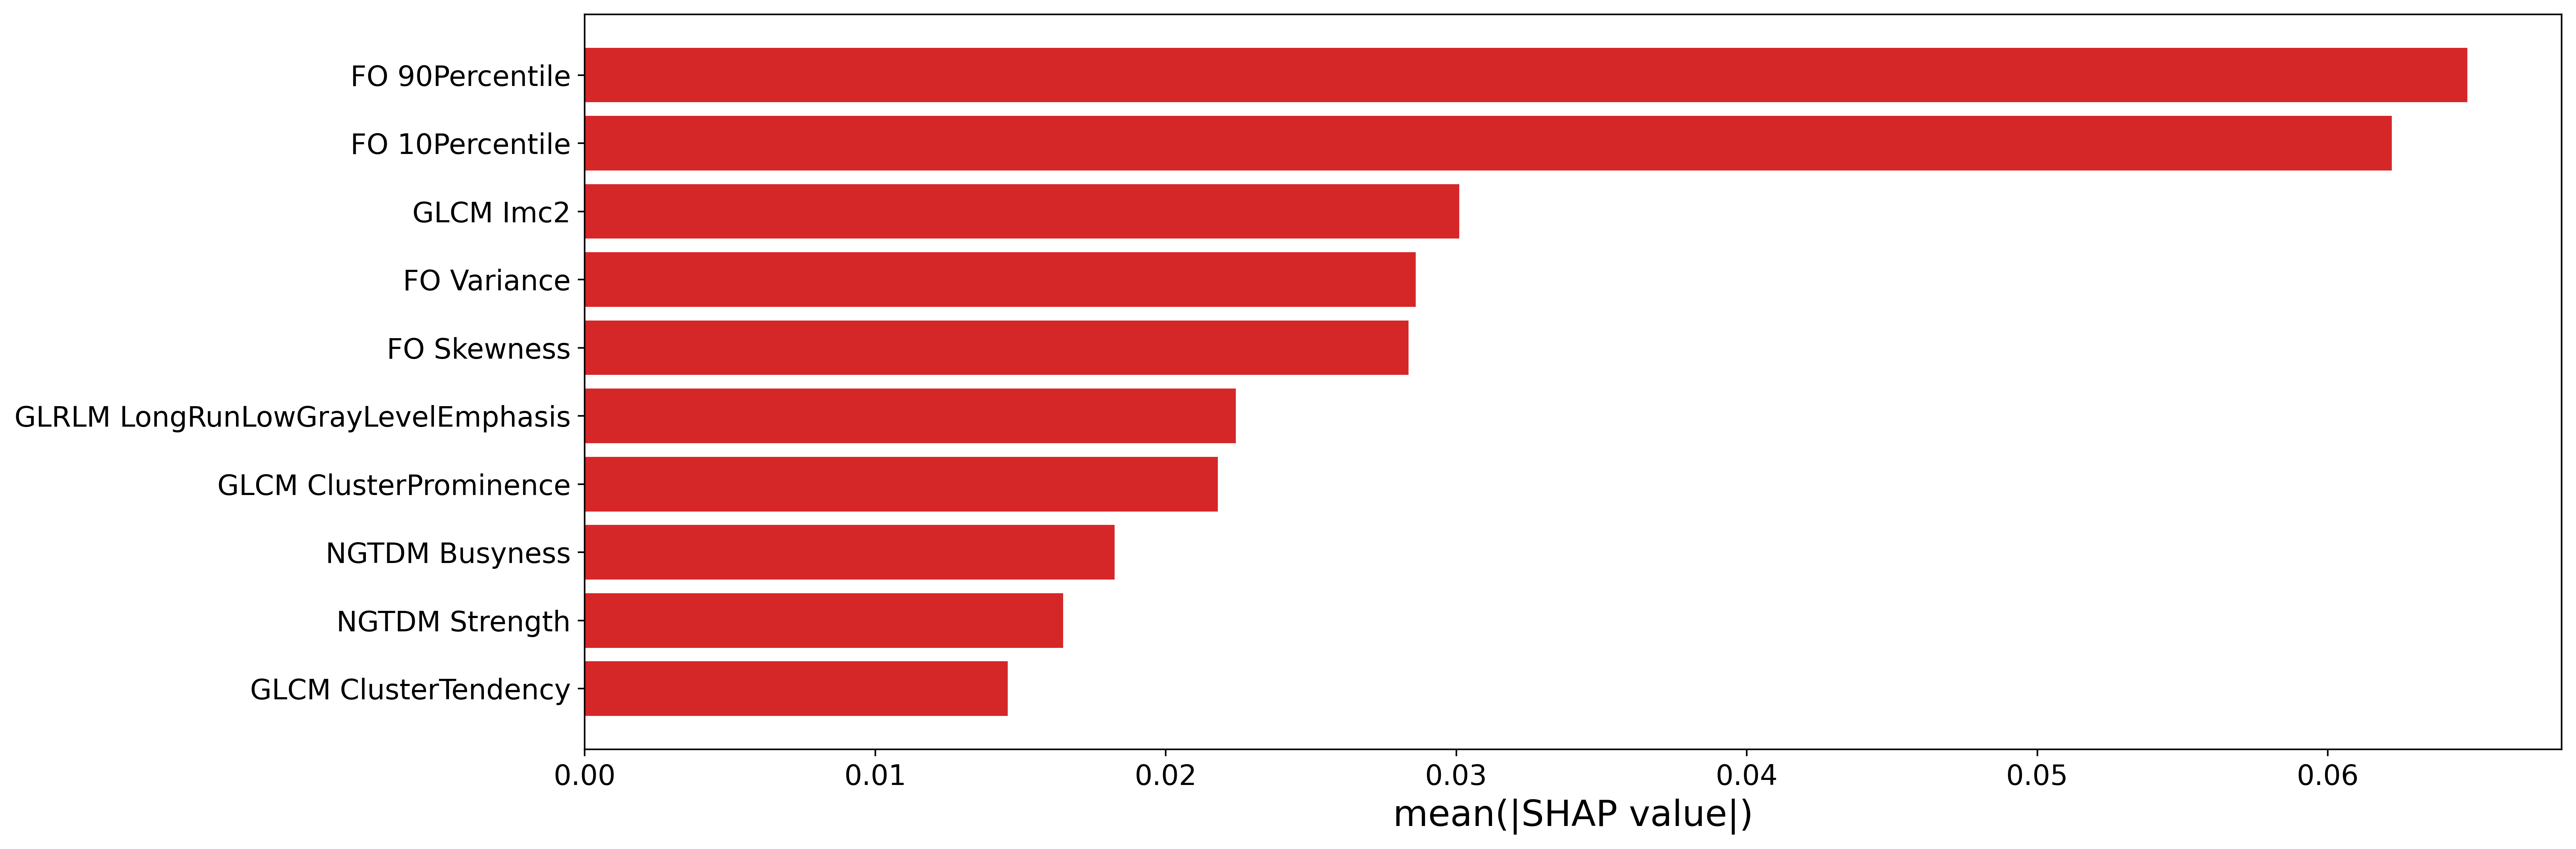

In [15]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Fit model
le = LabelEncoder()
y_encoded = le.fit_transform(y)
rf = RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3
    )
rf.fit(X, y_encoded)

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_values_class1 = shap_values[:, :, 1]

# BEESWARM PLOT (fully SHAP native)
shap.summary_plot(
    shap_values_class1,
    X,
    feature_names=X.columns,
    plot_size=(18, 6),
    max_display=10,
    show=False
)

#plt.title("SHAP Summary Plot (Class 1: Luminal)", fontsize=20)
plt.xlabel("SHAP value (impact on model output)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("../plots/shap_beeswarm.png", dpi=400)
plt.show()

# BAR PLOT (manual horizontal with correct ranking)
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-10:][::-1]  # sort descending directly
top_features = X.columns[top_indices]
top_values = mean_abs_shap[top_indices]

plt.figure(figsize=(18, 6), dpi=400)
plt.barh(range(len(top_features)), top_values, color="#d62728")

plt.yticks(range(len(top_features)), top_features, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("mean(|SHAP value|)", fontsize=18)
#plt.title("Mean SHAP Value (Feature Importance)", fontsize=20)
plt.gca().invert_yaxis()  # highest feature at top

plt.tight_layout()
plt.savefig("../plots/shap_bar.png", dpi=400)
plt.show()


### SHAP (One fold)

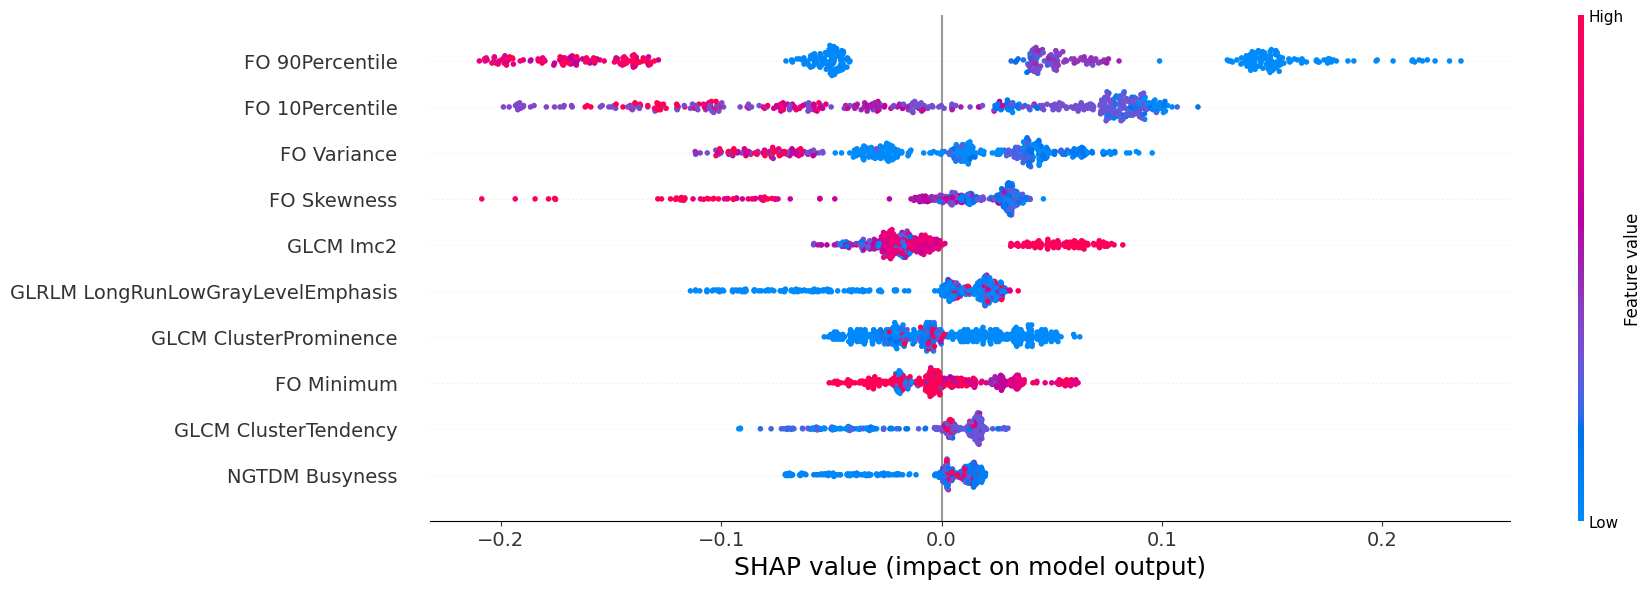

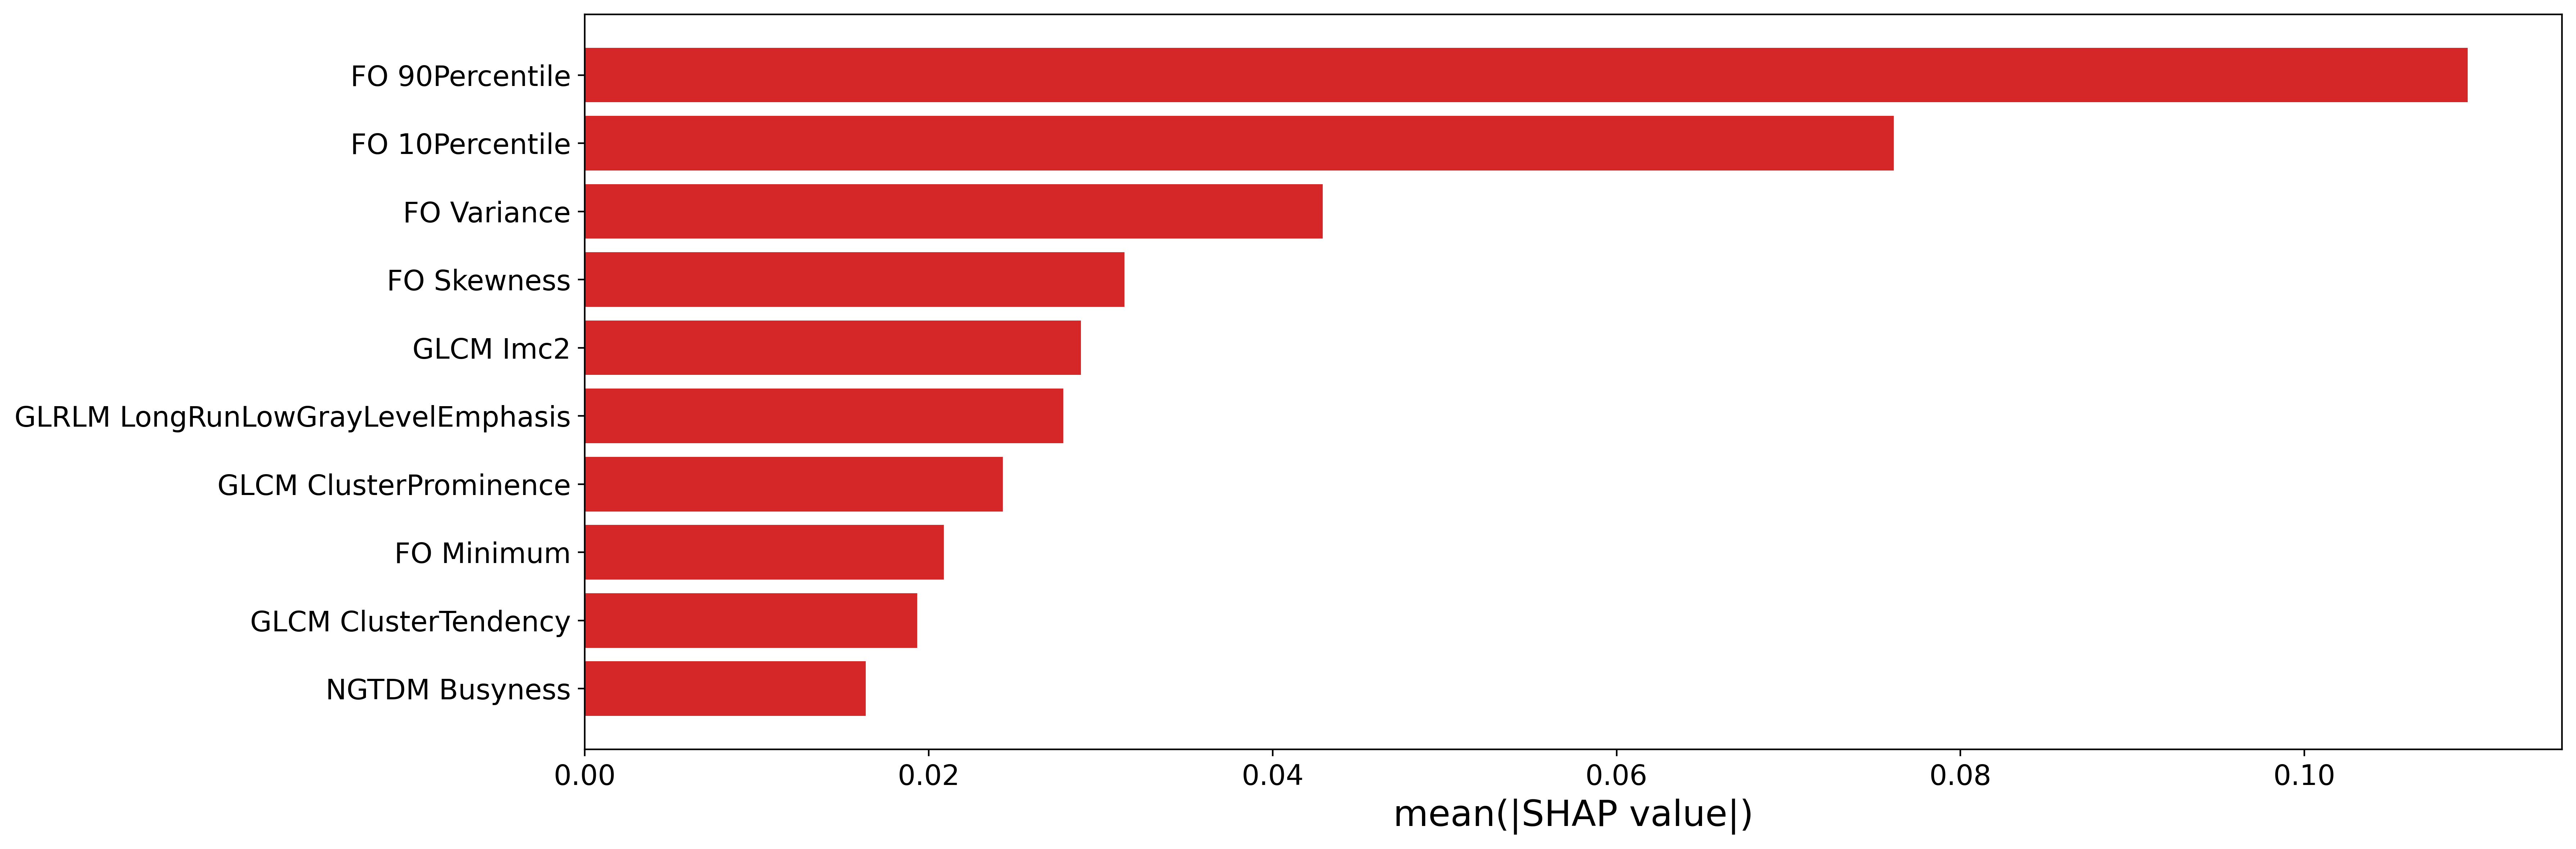

In [16]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Create CV split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(cv.split(X, y_encoded))  # just the first fold

# Split data
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Compute SHAP on validation fold
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_val)
shap_values_class1 = shap_values[:, :, 1]

# === BEESWARM PLOT ===
shap.summary_plot(
    shap_values_class1,
    X_val,
    feature_names=X.columns,
    plot_size=(18, 6),
    max_display=10,
    show=False
)

plt.xlabel("SHAP value (impact on model output)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("../plots/shap_beeswarm_onefold.png", dpi=400)
plt.show()

# === BAR PLOT ===
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-10:][::-1]
top_features = X.columns[top_indices]
top_values = mean_abs_shap[top_indices]

plt.figure(figsize=(18, 6), dpi=400)
plt.barh(range(len(top_features)), top_values, color="#d62728")
plt.yticks(range(len(top_features)), top_features, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("mean(|SHAP value|)", fontsize=18)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../plots/shap_bar_onefold.png", dpi=400)
plt.show()


### Re-creating Supplementary Plots

### Correlation Maps

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covarianc

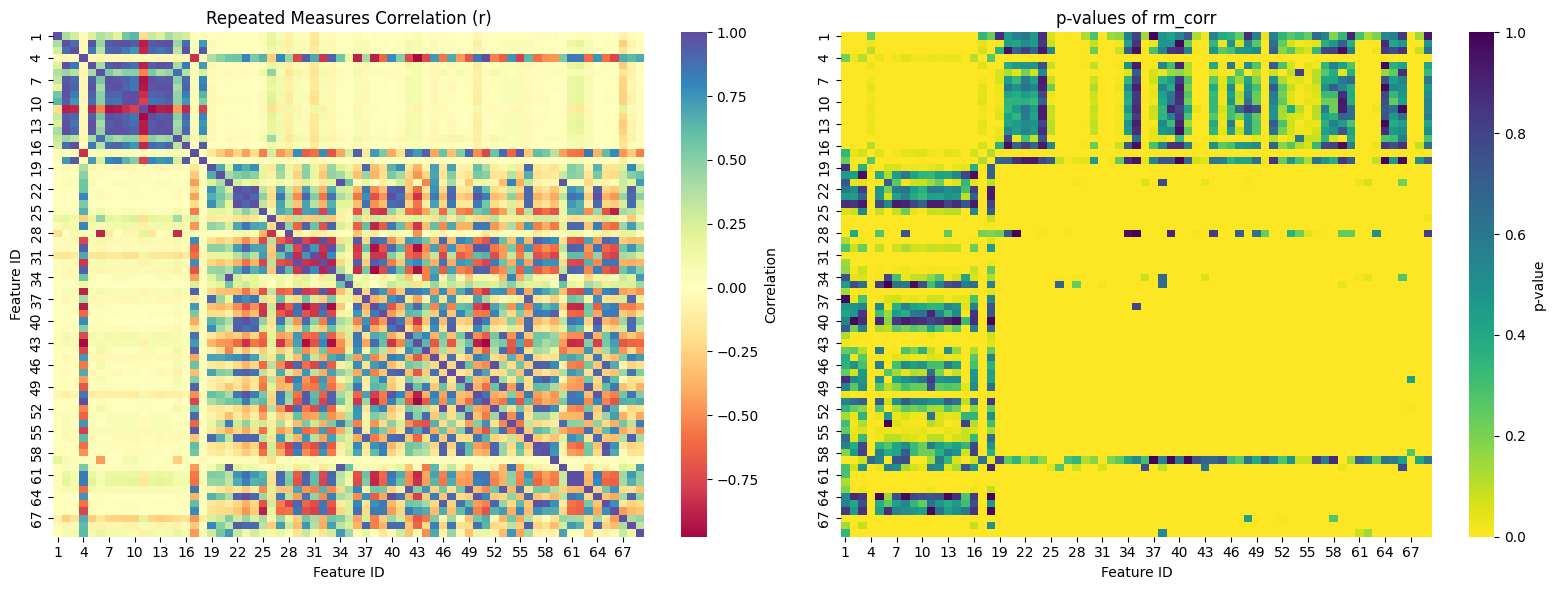

In [ ]:
# Subset to selected KW features (add 'PatientName')
df_selected = df_combined[selected_features_kw + ['PatientName']]

# Compute repeated measures correlation
n = len(selected_features_kw)
corr_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            corr_matrix[i, j] = 1
            pval_matrix[i, j] = 0
        else:
            res = pg.rm_corr(data=df_selected, x=selected_features_kw[i], y=selected_features_kw[j], subject='PatientName')
            corr_matrix[i, j] = res['r'].values[0]
            pval_matrix[i, j] = res['pval'].values[0]  # <- fixed here


# Convert to labeled DataFrames
corr_df = pd.DataFrame(corr_matrix, index=range(1, n+1), columns=range(1, n+1))
pval_df = pd.DataFrame(pval_matrix, index=range(1, n+1), columns=range(1, n+1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_df, ax=axes[0], cmap='Spectral', center=0, cbar_kws={'label': 'Correlation'})
axes[0].set_title("Repeated Measures Correlation (r)")
axes[0].set_xlabel("Feature ID")
axes[0].set_ylabel("Feature ID")

sns.heatmap(pval_df, ax=axes[1], cmap='viridis_r', vmin=0, vmax=1, cbar_kws={'label': 'p-value'})
axes[1].set_title("p-values of rm_corr")
axes[1].set_xlabel("Feature ID")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../plots/rm_corr_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()


### Per-feature Scoring

In [ ]:
# Load your data (replace with your actual file if needed)
# df_combined = pd.read_csv("df_combined_corrected.csv")

# Define predictors and target
target_col = "Model"
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns

# 5-fold CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42))
}

# Per-feature scoring
results = []
for i, feature in enumerate(feature_cols, start=1):
    row = {"ID": i, "Feature": feature}
    for name, model in models.items():
        X = df_combined[[feature]]
        y = df_combined[target_col]
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
        row[name] = scores.mean()
    row["Average"] = np.mean([row["Random Forest"], row["Gradient Boosting"], row["SVM"]])
    results.append(row)

# Final table
df_scores = pd.DataFrame(results)
df_scores = df_scores[["ID", "Feature", "Random Forest", "Gradient Boosting", "SVM", "Average"]]
df_scores = df_scores.sort_values("Average", ascending=False).reset_index(drop=True)


# Optionally save to CSV
# df_scores.to_csv("feature_scores_table_ST4.csv", index=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_scores)


,ID,Feature,Random Forest,Gradient Boosting,SVM,Average
0,3,FO Energy,1.000000,0.997357,0.864635,0.953997
1,16,FO TotalEnergy,1.000000,0.997357,0.864635,0.953997
2,2,FO 90Percentile,1.000000,1.000000,0.782180,0.927393
3,14,FO RootMeanSquared,1.000000,1.000000,0.769837,0.923279
4,9,FO Mean,1.000000,0.998675,0.739858,0.912844
5,10,FO Median,1.000000,0.986775,0.738093,0.908289
6,18,FO Variance,1.000000,0.947537,0.688266,0.878601
7,8,FO MeanAbsoluteDeviation,1.000000,0.922842,0.708557,0.877133
8,13,FO RobustMeanAbsoluteDeviation,1.000000,0.917114,0.710763,0.875959
9,1,FO 10Percentile,1.000000,0.918867,0.691772,0.870213


In [ ]:
import pandas as pd

# Step 1: Extract discarded features (those not passing BH correction at FDR < 0.25)
discarded_df = kw_df[~kw_df["Keep"]].copy()

# Step 2: Add ranks (based on original p-value, ascending)
discarded_df["rank"] = discarded_df["p_value"].rank(method="first").astype(int)

# Step 3: Sort by p-value
discarded_df_sorted = discarded_df.sort_values("p_value")[["p_value", "rank", "p_adj"]]
discarded_df_sorted = discarded_df_sorted.rename(columns={"p_adj": "corrected value"})
discarded_df_sorted.index.name = "Feature Name"

# Optional: display full table
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(discarded_df_sorted)

# Optional: export to CSV
# discarded_df_sorted.to_csv("Table_ST3_Discarded_Features.csv")


,p_value,rank,corrected value
Feature Name,,,
GLCM DifferenceEntropy,0.210026,1,0.279035
GLDM LargeDependenceHighGrayLevelEmphasis,0.218651,2,0.286402
GLCM SumAverage,0.245756,4,0.313086
GLCM JointAverage,0.245756,3,0.313086
GLCM Autocorrelation,0.320261,5,0.402490
NGTDM Complexity,0.334047,6,0.414219
GLRLM HighGrayLevelRunEmphasis,0.383103,7,0.468797
GLCM Correlation,0.423582,8,0.509530
GLDM DependenceVariance,0.427348,9,0.509530


### KW P Values

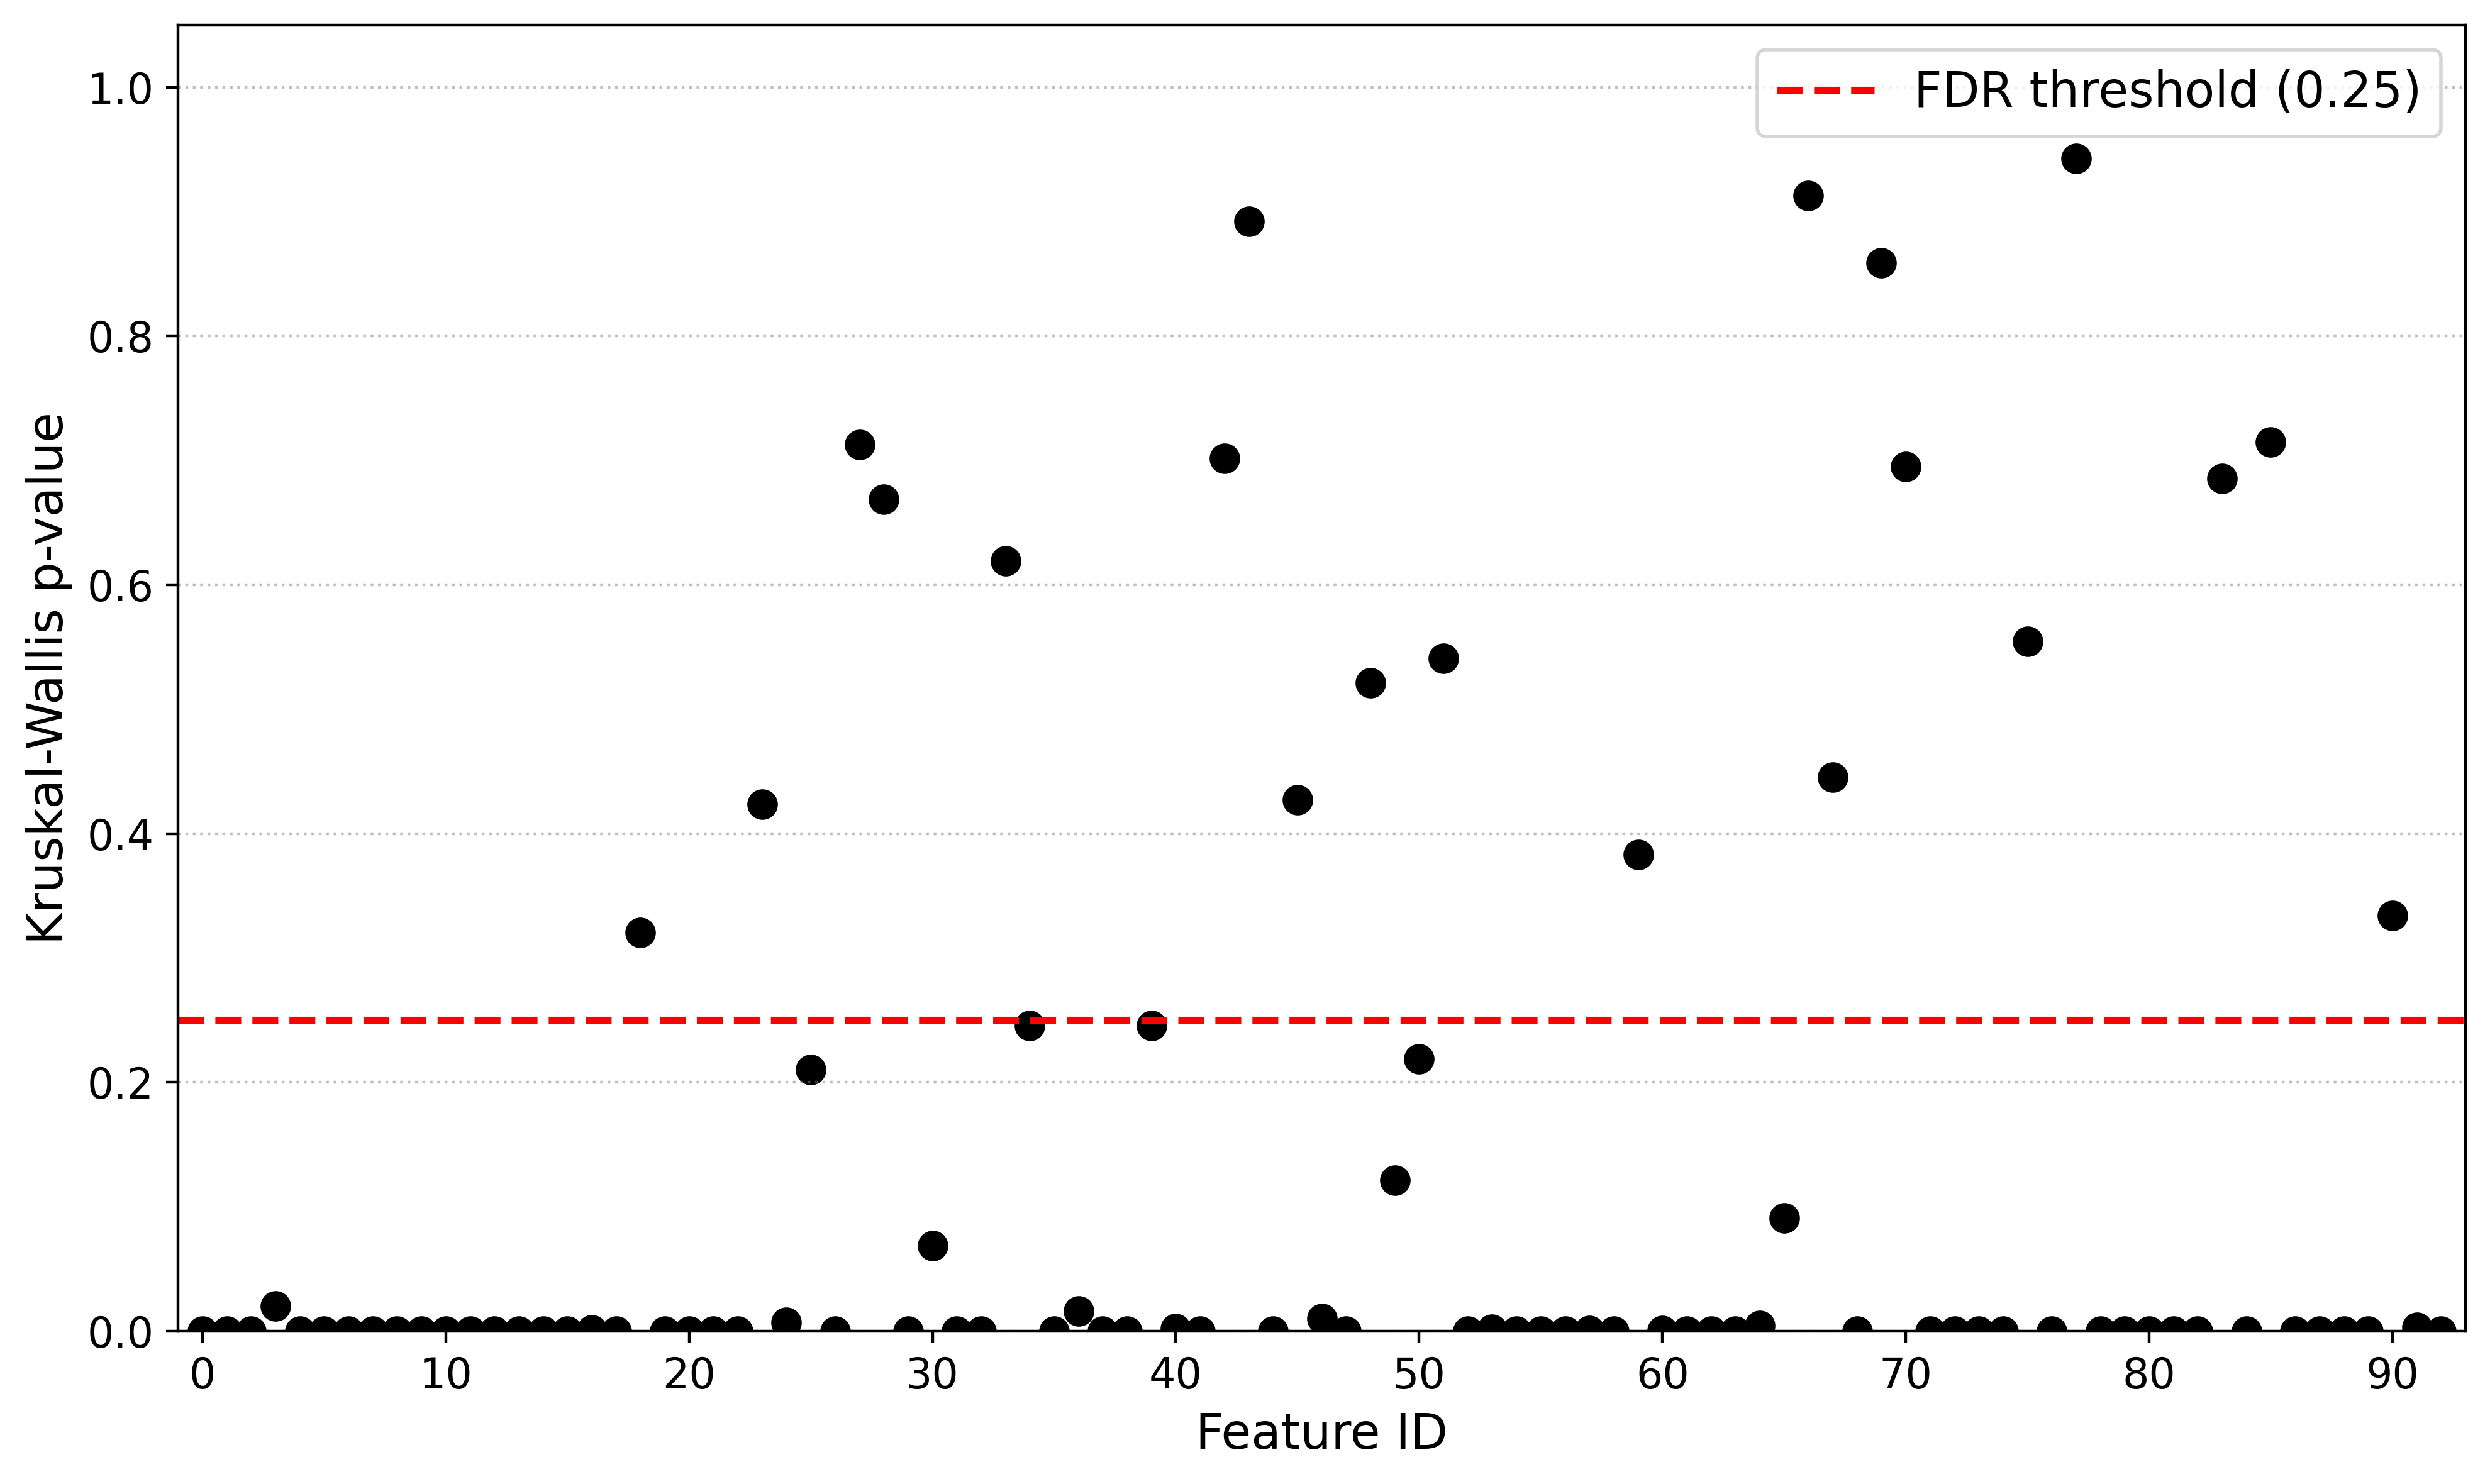

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reset index to access feature ID numerically
kw_df_plot = kw_df.reset_index()

plt.figure(figsize=(10, 6), dpi=400)

# Scatter plot
plt.scatter(range(len(kw_df_plot)), kw_df_plot["p_value"], color="black", s=60)

# FDR threshold line
plt.axhline(y=0.25, color="red", linestyle="--", linewidth=2, label="FDR threshold (0.25)")

# Axis limits and labels
plt.ylim(0, 1.05)
plt.xlim(-1, len(kw_df_plot))
plt.ylabel("Kruskal-Wallis p-value", fontsize=14)
plt.xlabel("Feature ID", fontsize=14)
plt.xticks(np.arange(0, len(kw_df_plot)+1, 10), fontsize=12)
plt.yticks(fontsize=12)

# Gridlines
plt.grid(axis="y", linestyle=":", color="grey", alpha=0.5)

# Optional legend
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("../plots/kw_pvalues.png", dpi=400)
plt.show()
